<a href="https://colab.research.google.com/github/Imran1hp/Deep-Learning-/blob/main/Neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [460]:
import sklearn

MAKING CLASSIFICATION DATA

In [461]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples,noise=0.03 , random_state=42)


In [462]:
len(X),len(y)

(1000, 1000)

In [463]:
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [464]:
import pandas as pd
circles = pd.DataFrame({"X1":X[ : , 0],
                        "X2":X[ : , 1],
                        "label":y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


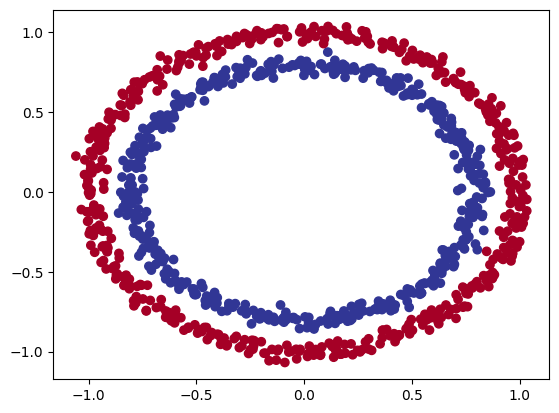

In [465]:
import matplotlib.pyplot as plt
plt.scatter (x=X[:,0],y=X[: , 1],c=y,cmap=plt.cm.RdYlBu)


In [466]:
X.shape , y.shape

((1000, 2), (1000,))

In [467]:
X


array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [468]:
X_sample = X[0]
y_sample = y[0]
X_sample , y_sample

(array([0.75424625, 0.23148074]), np.int64(1))

## Turn data into tensor and create train and test split

In [469]:
import torch



In [470]:
type (X)

numpy.ndarray

In [471]:
X = torch.from_numpy(X).type(torch.float)

y = torch.from_numpy(y).type(torch.float)


In [472]:
type(X) , X.dtype

(torch.Tensor, torch.float32)

##Split Data

In [473]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y ,
                                                       test_size =0.2,
                                                       random_state=42)


In [474]:
len(X_train),len(y_train),len(X_test) ,len(y_test)

(800, 800, 200, 200)

## Build our model

In [475]:
import torch
from torch import nn

In [476]:
device =''
if torch.cuda.is_available():
  device = 'cuda'
else:
  device ="cpu"


In [477]:
device

'cuda'

In [478]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2 ,out_features = 5)  # Take in 2 features and upscales to 5 feature
    self.layer_2 = nn.Linear(in_features = 5 , out_features =1 ) # Take in 5 feature from pervious layers and output a single feature

  def forward (self ,x):
    return self.layer_2(self.layer_1(x))  # x-> layer_1 -> layer_2 -> output


model_0 = CircleModelV0().to(device)
model_0





CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [479]:
device

'cuda'

In [480]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [481]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [482]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3041, -0.0775],
                      [-0.5293,  0.6441],
                      [-0.5190,  0.3779],
                      [ 0.2485,  0.2298],
                      [-0.3823,  0.6427]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.1554,  0.0910, -0.6231,  0.2968, -0.1061], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2049,  0.3841,  0.0997, -0.2474, -0.2264]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.0214], device='cuda:0'))])

In [483]:
with torch.inference_mode():
  untrain_preds = model_0(X_test)

untrain_preds.shape , len(untrain_preds)

(torch.Size([200, 1]), 200)

## loss function and optimizer

In [484]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_0.parameters() , lr =0.1)

In [485]:
def accuracy (y_true , y_preds ):
  correct = torch.eq(y_true , y_preds).sum().item()
  acc = (correct/len(y_preds )) *100
  return acc

In [486]:
model_0.eval()
with torch.inference_mode():
  logits_preds = model_0(X_test)[:5]
logits_preds

tensor([[ 0.0004],
        [-0.0377],
        [-0.0430],
        [ 0.0133],
        [-0.2707]], device='cuda:0')

In [487]:
y_test[:5]

tensor([1., 0., 1., 0., 1.], device='cuda:0')

#make them same y_test and prediction

In [488]:
## sigmoid activation function
y_preds_probs = torch.sigmoid(logits_preds)

y_preds_probs

tensor([[0.5001],
        [0.4906],
        [0.4893],
        [0.5033],
        [0.4327]], device='cuda:0')

if y < 0.5 the preds is 0 and if y > 0.5 then preds is 1

In [489]:
y_preds = torch.round(y_preds_probs)
y_preds

tensor([[1.],
        [0.],
        [0.],
        [1.],
        [0.]], device='cuda:0')

## Building a training and testing loop

In [490]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs =100

for epoch in range(epochs):

  model_0.train()

  #Forward pass

  y_logits = model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits)) # turm logits ->pred probabilitys -> pred labels

  # calculate the loss/ accuracy
  loss = loss_fn(y_logits , y_train)

  acc = accuracy( y_true = y_train , y_preds = y_preds )

  # optimizer zero grad
  optimizer.zero_grad()

  # loss backward  ( backpropagetion )
  loss.backward()

  #optimzier step   ( gradient descent )
  optimizer.step()

  ##testing
  model_0.eval()
  with torch.inference_mode():

    # Forward pass
    test_logits  = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    # Calculate the test loss / accuarcy
    test_loss = loss_fn (test_logits , y_test)

    test_acc = accuracy(y_true = y_test , y_preds = test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}  | Train_loss: {loss:.5f} | Train_ACC: {acc:.2f}")

    print(f"Epoch: {epoch}  | Test_loss: {test_loss:.5f} | Test_ACC: {test_acc:.2f}")




Epoch: 0  | Train_loss: 0.69713 | Train_ACC: 46.75
Epoch: 0  | Test_loss: 0.69687 | Test_ACC: 43.50
Epoch: 10  | Train_loss: 0.69504 | Train_ACC: 48.50
Epoch: 10  | Test_loss: 0.69495 | Test_ACC: 46.50
Epoch: 20  | Train_loss: 0.69416 | Train_ACC: 49.38
Epoch: 20  | Test_loss: 0.69412 | Test_ACC: 44.50
Epoch: 30  | Train_loss: 0.69375 | Train_ACC: 50.00
Epoch: 30  | Test_loss: 0.69372 | Test_ACC: 46.50
Epoch: 40  | Train_loss: 0.69355 | Train_ACC: 50.38
Epoch: 40  | Test_loss: 0.69353 | Test_ACC: 47.00
Epoch: 50  | Train_loss: 0.69343 | Train_ACC: 50.38
Epoch: 50  | Test_loss: 0.69342 | Test_ACC: 50.50
Epoch: 60  | Train_loss: 0.69336 | Train_ACC: 49.75
Epoch: 60  | Test_loss: 0.69337 | Test_ACC: 50.50
Epoch: 70  | Train_loss: 0.69330 | Train_ACC: 50.00
Epoch: 70  | Test_loss: 0.69335 | Test_ACC: 52.50
Epoch: 80  | Train_loss: 0.69326 | Train_ACC: 49.50
Epoch: 80  | Test_loss: 0.69335 | Test_ACC: 55.00
Epoch: 90  | Train_loss: 0.69323 | Train_ACC: 49.25
Epoch: 90  | Test_loss: 0.69336 

## Loss is to high we need to do some hyperparameters tunning  to make the model more acccurate  

In [491]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2 , out_features=10)
    self.layer_2 = nn.Linear(in_features = 10 , out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10 , out_features = 1)
  def forward(self , x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [492]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [493]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)

def traing_loop (epochs, model, learning_rate=0.01):




  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(params = model.parameters(), lr= learning_rate )


  epochs = epochs
  for epoch in range(epochs):

    model.train()

    #Forward pass
    logits_preds = model(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits_preds))


    # calculate loss/accuracy

    loss = loss_fn( logits_preds , y_train)
    acc = accuracy(y_true = y_train , y_preds = y_preds)

    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    #gradient decsent
    optimizer.step()



    model.eval()
    with torch.inference_mode():

     test_logits = model(X_test).squeeze()
     test_preds = torch.round(torch.sigmoid(test_logits))

     test_loss = loss_fn( test_logits , y_test )
     test_acc = accuracy(y_test , test_preds)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch}  | Train_loss: {loss:.5f} | Train_ACC: {acc:.2f}")

      print(f"Epoch: {epoch}  | Test_loss: {test_loss:.5f} | Test_ACC: {test_acc:.2f}")






In [494]:
traing_loop(1000 , model_1 , 0.03)

Epoch: 0  | Train_loss: 0.69396 | Train_ACC: 50.88
Epoch: 0  | Test_loss: 0.69261 | Test_ACC: 51.00
Epoch: 100  | Train_loss: 0.69339 | Train_ACC: 50.50
Epoch: 100  | Test_loss: 0.69296 | Test_ACC: 48.00
Epoch: 200  | Train_loss: 0.69317 | Train_ACC: 49.62
Epoch: 200  | Test_loss: 0.69335 | Test_ACC: 53.00
Epoch: 300  | Train_loss: 0.69307 | Train_ACC: 50.50
Epoch: 300  | Test_loss: 0.69369 | Test_ACC: 47.50
Epoch: 400  | Train_loss: 0.69302 | Train_ACC: 50.88
Epoch: 400  | Test_loss: 0.69395 | Test_ACC: 46.00
Epoch: 500  | Train_loss: 0.69300 | Train_ACC: 51.12
Epoch: 500  | Test_loss: 0.69415 | Test_ACC: 47.00
Epoch: 600  | Train_loss: 0.69299 | Train_ACC: 51.12
Epoch: 600  | Test_loss: 0.69429 | Test_ACC: 46.50
Epoch: 700  | Train_loss: 0.69298 | Train_ACC: 51.00
Epoch: 700  | Test_loss: 0.69440 | Test_ACC: 46.00
Epoch: 800  | Train_loss: 0.69298 | Train_ACC: 51.50
Epoch: 800  | Test_loss: 0.69448 | Test_ACC: 46.00
Epoch: 900  | Train_loss: 0.69298 | Train_ACC: 51.50
Epoch: 900  | T

#Building a model with non-linearity

In [495]:
class CircleModelV2(nn.Module):
  def __init__(self):
   super().__init__()

   self.layer_1 = nn.Linear(in_features = 2 , out_features = 10)
   self.layer_2 = nn.Linear(in_features = 10 , out_features = 10)
   self.layer_3 = nn.Linear(in_features = 10 , out_features = 1)
   self.relu = nn.ReLU()

  def forward(self , x):
    return self.layer_3(self.layer_2(self.relu(self.layer_1(x))))


model_2 = CircleModelV2()
model_2


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [496]:
model_2 = model_2.to(device)

In [497]:
next(model_2.parameters()).device

device(type='cuda', index=0)

In [498]:
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [499]:
traing_loop(epochs=1000,model = model_2 ,learning_rate = 0.1)

Epoch: 0  | Train_loss: 0.69441 | Train_ACC: 50.00
Epoch: 0  | Test_loss: 0.69412 | Test_ACC: 50.00
Epoch: 100  | Train_loss: 0.68984 | Train_ACC: 52.38
Epoch: 100  | Test_loss: 0.68935 | Test_ACC: 51.00
Epoch: 200  | Train_loss: 0.68707 | Train_ACC: 58.25
Epoch: 200  | Test_loss: 0.68601 | Test_ACC: 59.00
Epoch: 300  | Train_loss: 0.68338 | Train_ACC: 53.87
Epoch: 300  | Test_loss: 0.68177 | Test_ACC: 58.00
Epoch: 400  | Train_loss: 0.67826 | Train_ACC: 53.87
Epoch: 400  | Test_loss: 0.67591 | Test_ACC: 57.00
Epoch: 500  | Train_loss: 0.67058 | Train_ACC: 53.25
Epoch: 500  | Test_loss: 0.66753 | Test_ACC: 58.00
Epoch: 600  | Train_loss: 0.65828 | Train_ACC: 59.13
Epoch: 600  | Test_loss: 0.65466 | Test_ACC: 59.00
Epoch: 700  | Train_loss: 0.63517 | Train_ACC: 71.75
Epoch: 700  | Test_loss: 0.63262 | Test_ACC: 75.00
Epoch: 800  | Train_loss: 0.59027 | Train_ACC: 85.88
Epoch: 800  | Test_loss: 0.59330 | Test_ACC: 87.00
Epoch: 900  | Train_loss: 0.51050 | Train_ACC: 94.12
Epoch: 900  | T

In [507]:
from numpy import float32
# creat a tensor

A = torch.arange(-10 ,10 , 1 ,dtype = torch.float32)


In [508]:
A.dtype

torch.float32

In [509]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

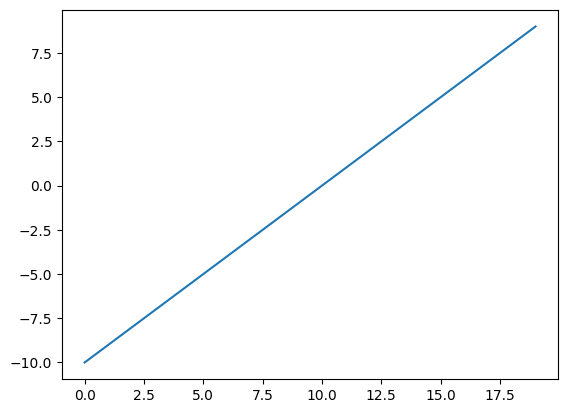

In [510]:
plt.plot(A)

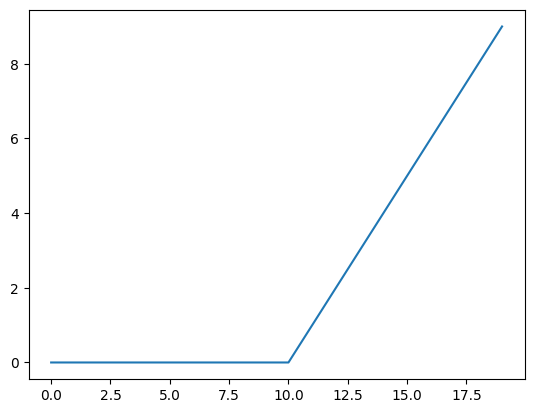

In [512]:
plt.plot(torch.relu(A))

In [516]:
def Relu(x:  torch.Tensor)-> torch.Tensor:
  return torch.maximum(torch.tensor(0),x)


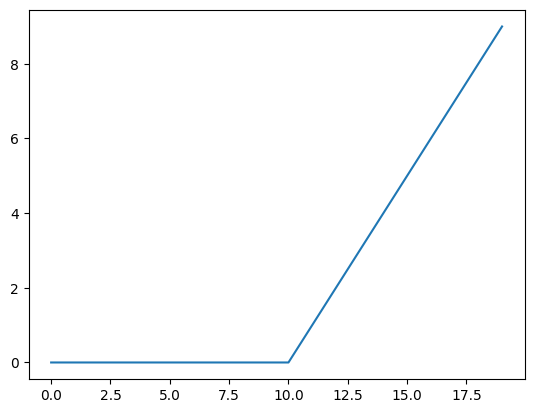

In [518]:
plt.plot(Relu(A))

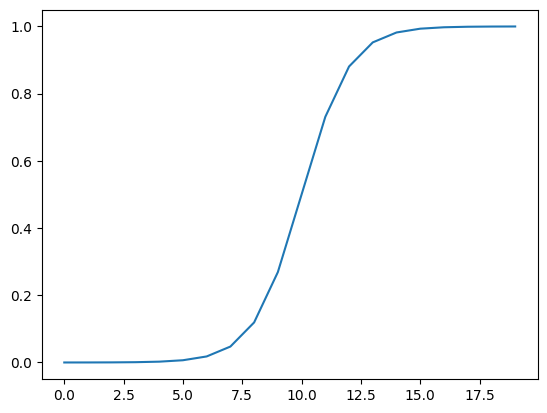

In [521]:
plt.plot(torch.sigmoid(A))

In [522]:
def Sigmoid(x):
  return 1/(1+torch.exp(-x))

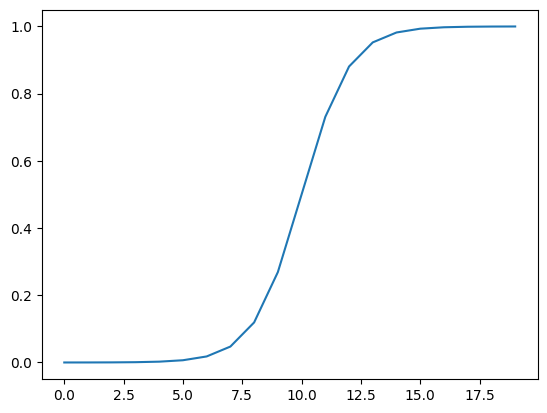

In [523]:
plt.plot(Sigmoid(A))